Cloning repository …
Clone complete.

Found 4 image(s) in 'fft_blur_repo1/images'

─────────────────────────────────────────────────────────────────
  Processing : img1.jpeg
  HF Ratio      : 0.1645
  Decay Slope   : -0.038735  (more negative = more blurred)
  Sparsity Ratio: 0.1246  (lower = more blurred)
  Decision      : Blurred


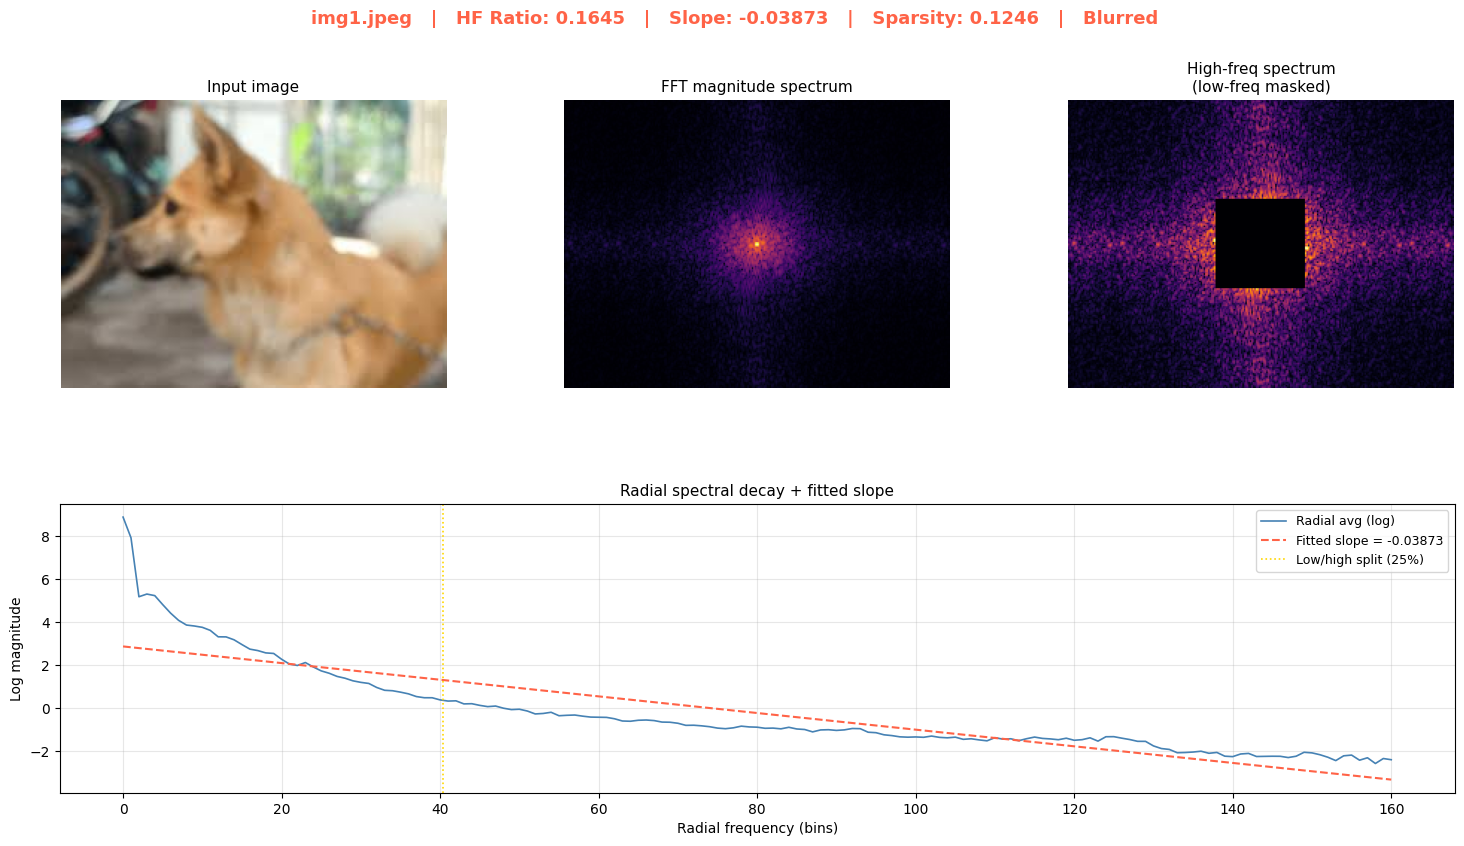

─────────────────────────────────────────────────────────────────
  Processing : img2.jpeg
  HF Ratio      : 0.6039
  Decay Slope   : -0.015400  (more negative = more blurred)
  Sparsity Ratio: 0.1435  (lower = more blurred)
  Decision      : Sharp


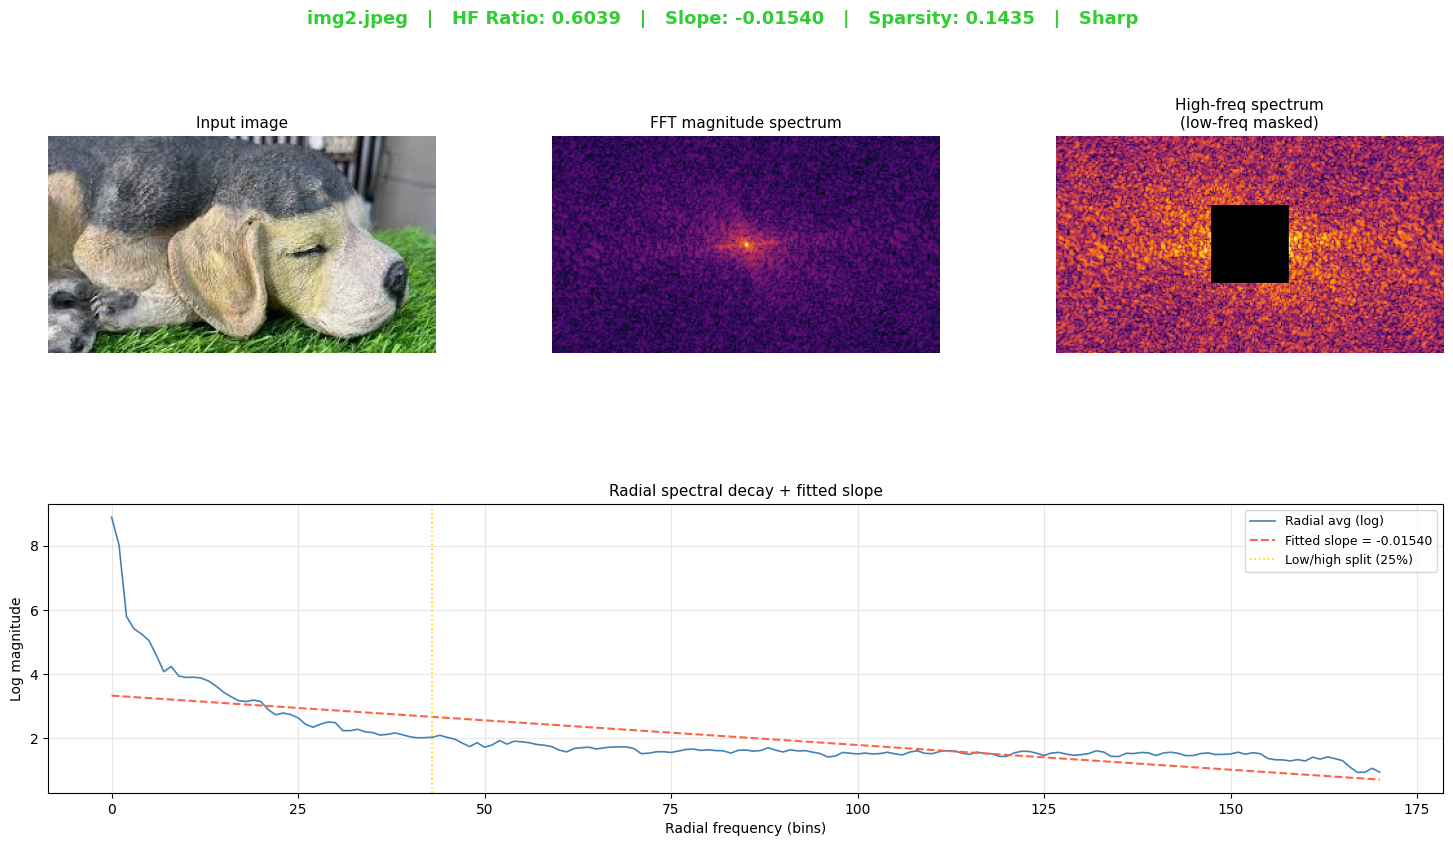

─────────────────────────────────────────────────────────────────
  Processing : img3.jpeg
  HF Ratio      : 0.1552
  Decay Slope   : -0.035983  (more negative = more blurred)
  Sparsity Ratio: 0.0939  (lower = more blurred)
  Decision      : Blurred


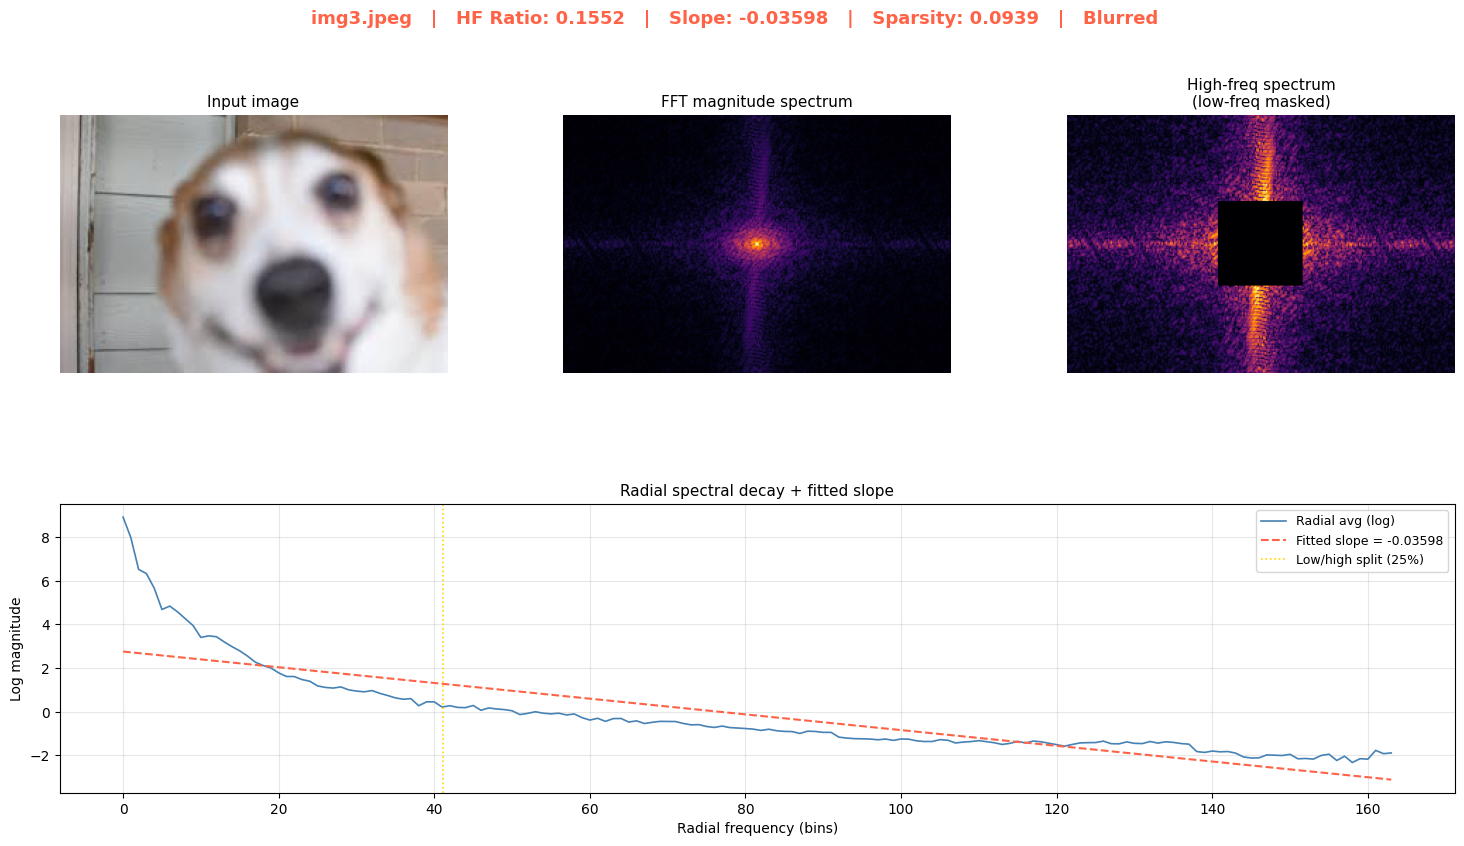

─────────────────────────────────────────────────────────────────
  Processing : img5.jpg
  HF Ratio      : 0.5851
  Decay Slope   : -0.010053  (more negative = more blurred)
  Sparsity Ratio: 0.1427  (lower = more blurred)
  Decision      : Sharp


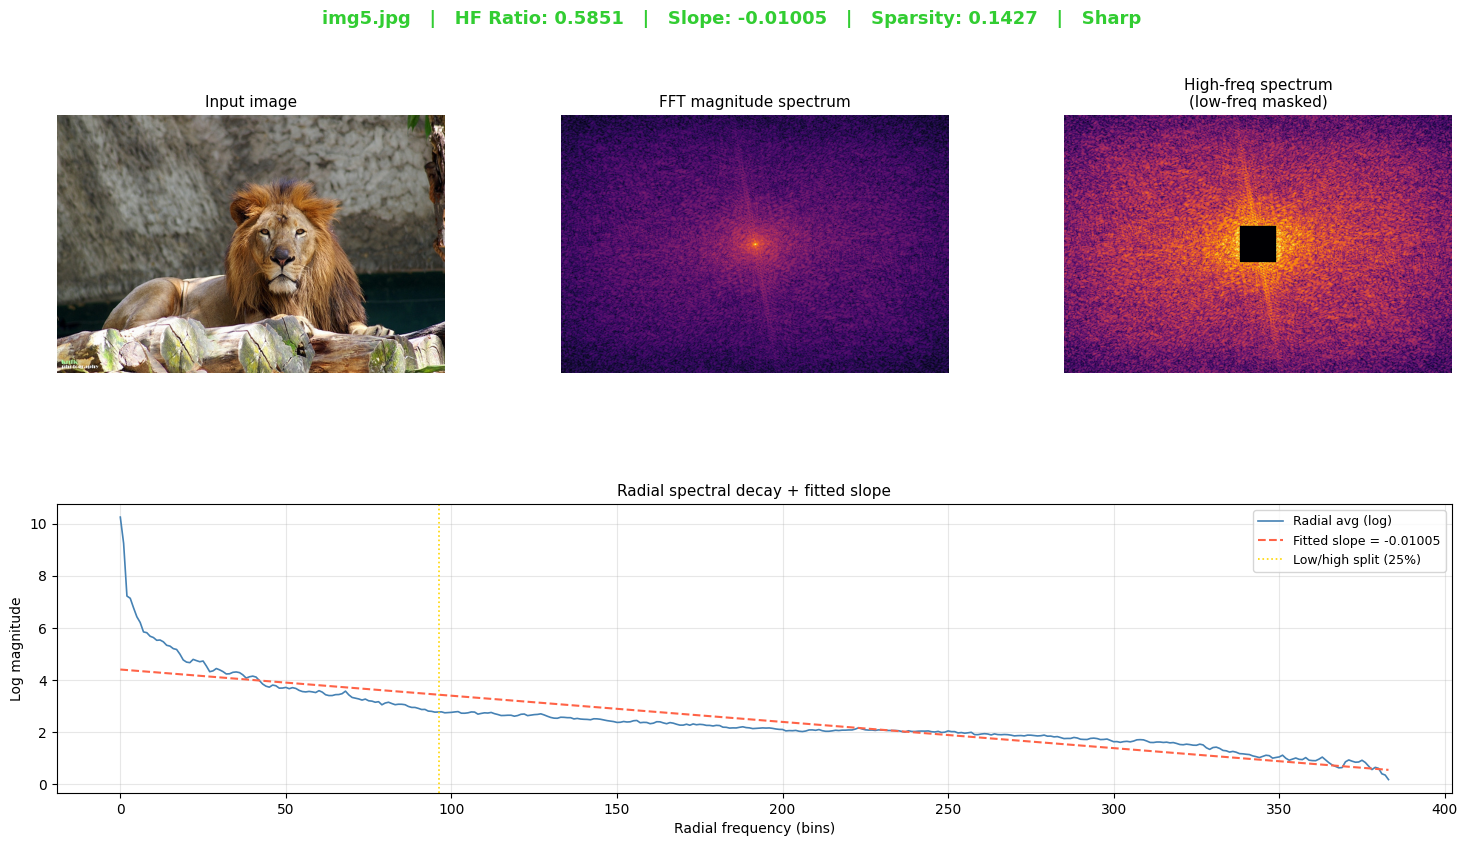


  RESULTS SUMMARY


,Image,HF_Ratio,Decay_Slope,Sparsity_Ratio,Result
0,img1.jpeg,0.1645,-0.038735,0.1246,Blurred
1,img2.jpeg,0.6039,-0.015400,0.1435,Sharp
2,img3.jpeg,0.1552,-0.035983,0.0939,Blurred
3,img5.jpg,0.5851,-0.010053,0.1427,Sharp



Total: 4  |  Sharp: 2  |  Blurred: 2
HF Ratio    — mean: 0.3772   std: 0.2511
Decay Slope — mean: -0.025043  std: 0.014432
Sparsity    — mean: 0.1262   std: 0.0232


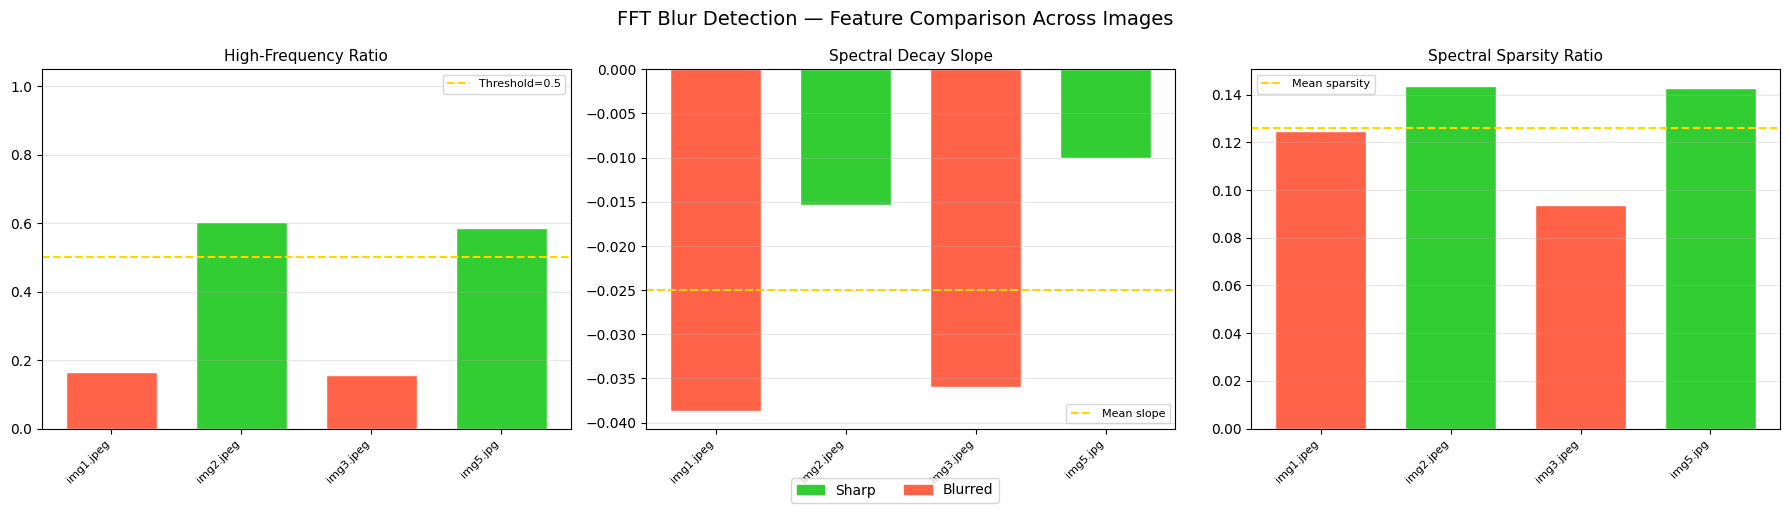


[INFO] Classifier skipped — need ≥ 6 images for a meaningful train/test split.
       Set RUN_CLASSIFIER = False to suppress this message.


In [1]:
# ── Imports ─────────────────────────────────────────────────
import os
import subprocess
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from numpy.fft import fft2, fftshift
from IPython.display import display
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

# ── 1. Clone GitHub Repository ───────────────────────────────
REPO_URL  = "https://github.com/dyno8646/Fast-Fourier-Transform-FFT-for-blur-detection-in-images.git"
REPO_DIR  = "fft_blur_repo1"
IMAGE_DIR = os.path.join(REPO_DIR, "images")

if not os.path.exists(REPO_DIR):
    print("Cloning repository …")
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    print("Clone complete.\n")
else:
    print("Repository already cloned.\n")

# ── 2. Tuneable Parameters ───────────────────────────────────
MASK_SIZE        = 30    # radius (px) of low-freq patch zeroed out
FREQ_THRESHOLD   = 0.25  # fraction of max radius → low/high split
HF_THRESHOLD     = 0.50  # HF ratio below this → "Blurred"
SPARSITY_STD_MUL = 1.0   # multiplier on std for sparsity threshold
USE_WINDOWING    = True  # apply Hann window before FFT
RUN_CLASSIFIER   = True  # train LR + SVM on extracted features

# ── 3. Preprocessing ─────────────────────────────────────────
def preprocess(img_bgr, use_windowing=USE_WINDOWING):
    """
    Converts to grayscale, applies intensity normalization [0,1],
    and optionally applies a 2D Hann window to suppress edge artifacts.

    Returns:
        img_gray_norm  – float32 grayscale array in [0, 1]
        img_windowed   – windowed version used for FFT
    """
    # Grayscale conversion
    if len(img_bgr.shape) == 2:
        gray = img_bgr.astype(np.float32)
    else:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Intensity normalization → [0, 1]
    norm = cv2.normalize(gray, None, 0.0, 1.0, cv2.NORM_MINMAX)

    # Hann windowing to reduce spectral leakage at boundaries
    if use_windowing:
        h, w = norm.shape
        hann_row = np.hanning(h).reshape(-1, 1)
        hann_col = np.hanning(w).reshape(1, -1)
        window   = hann_row * hann_col          # 2-D Hann window
        windowed = norm * window
    else:
        windowed = norm.copy()

    return norm, windowed


# ── 4. Frequency Transformation ─────────────────────────────
def compute_fft(image_windowed):
    """
    Computes 2-D FFT, shifts DC to centre, returns magnitude spectrum.

    Returns:
        fshift         – complex shifted FFT
        magnitude_raw  – |fshift|
        magnitude_log  – log(|fshift| + 1) for visualisation
    """
    fshift        = fftshift(fft2(image_windowed))
    magnitude_raw = np.abs(fshift)
    magnitude_log = np.log(magnitude_raw + 1)
    return fshift, magnitude_raw, magnitude_log


# ── 5. High-Frequency Energy Ratio ───────────────────────────
def compute_hf_ratio(magnitude_raw, freq_threshold=FREQ_THRESHOLD):
    """
    Partitions spectrum into low/high by radial distance.
    Returns HF ratio = high_energy / total_energy  ∈ [0, 1].
    Higher ratio → sharper image.
    """
    h, w = magnitude_raw.shape
    cx, cy = w // 2, h // 2
    y, x   = np.ogrid[:h, :w]
    r      = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    max_r  = r.max()

    low_mask   = r <= freq_threshold * max_r
    low_energy = np.sum(magnitude_raw[low_mask])
    high_energy= np.sum(magnitude_raw[~low_mask])
    hf_ratio   = high_energy / (low_energy + high_energy + 1e-10)
    return hf_ratio, r, max_r


# ── 6. Radial Spectral Decay Analysis ────────────────────────
def compute_radial_decay(magnitude_raw, r, max_r):
    """
    Computes radial-average of the magnitude spectrum and fits a
    log-linear decay curve. The slope serves as a blur indicator:
    blurred images → steeper negative slope.

    Returns:
        radial_avg – 1-D array of mean magnitude per radial bin
        slope      – log-linear decay slope (more negative = more blur)
        intercept  – intercept of fitted line
    """
    num_bins   = int(max_r)
    radial_avg = np.zeros(num_bins)

    for i in range(num_bins):
        ring_mask = (r >= i) & (r < i + 1)
        if ring_mask.sum() > 0:
            radial_avg[i] = magnitude_raw[ring_mask].mean()

    # Log-linear fit: log(radial_avg) = slope * freq + intercept
    valid      = radial_avg > 0
    freq_axis  = np.arange(num_bins)[valid]
    log_values = np.log(radial_avg[valid] + 1e-10)
    slope, intercept = np.polyfit(freq_axis, log_values, 1)

    return radial_avg, slope, intercept


# ── 7. Spectral Sparsity Measure ─────────────────────────────
def compute_sparsity(magnitude_raw, r, max_r,
                     freq_threshold=FREQ_THRESHOLD,
                     std_multiplier=SPARSITY_STD_MUL):
    """
    Counts significant high-frequency components above
    (mean + std_multiplier × std) in the HF region.
    Lower sparsity ratio → more blurred.

    Returns:
        sparsity_ratio – fraction of HF pixels above threshold
        sparsity_count – raw count of peaks
    """
    hf_region         = magnitude_raw[r > freq_threshold * max_r]
    sparse_thresh     = hf_region.mean() + std_multiplier * hf_region.std()
    sparsity_count    = int(np.sum(hf_region > sparse_thresh))
    sparsity_ratio    = sparsity_count / (hf_region.size + 1e-10)
    return sparsity_ratio, sparsity_count


# ── 8. High-Frequency Mask Spectrum (for visualisation) ──────
def compute_masked_spectrum(fshift, magnitude_log, mask_size=MASK_SIZE):
    """
    Zeros out low-freq centre patch and returns log-scale spectrum.
    """
    h, w = fshift.shape
    cx, cy = w // 2, h // 2
    fshift_filtered = fshift.copy()
    fshift_filtered[cy - mask_size:cy + mask_size,
                    cx - mask_size:cx + mask_size] = 0
    magnitude_filt  = np.log(np.abs(fshift_filtered) + 1)
    return magnitude_filt


# ── 9. Full Detection Pipeline (single image) ────────────────
def detect_blur(img_bgr):
    """
    Runs the complete FFT blur detection pipeline on one image.

    Returns a dict with all spectral features and visual arrays.
    """
    # Preprocessing
    img_norm, img_windowed = preprocess(img_bgr)

    # FFT
    fshift, mag_raw, mag_log = compute_fft(img_windowed)

    # HF ratio
    hf_ratio, r, max_r = compute_hf_ratio(mag_raw)

    # Radial decay
    radial_avg, slope, intercept = compute_radial_decay(mag_raw, r, max_r)

    # Sparsity
    sparsity_ratio, sparsity_count = compute_sparsity(mag_raw, r, max_r)

    # Masked spectrum for visualisation
    mag_filt = compute_masked_spectrum(fshift, mag_log)

    return {
        "hf_ratio"      : hf_ratio,
        "slope"         : slope,
        "intercept"     : intercept,
        "sparsity_ratio": sparsity_ratio,
        "sparsity_count": sparsity_count,
        "radial_avg"    : radial_avg,
        "mag_log"       : mag_log,
        "mag_filt"      : mag_filt,
        "r"             : r,
        "max_r"         : max_r,
    }


# ── 10. Image Visualisation ───────────────────────────────
def visualise_image(fname, img_bgr, res):
    """
    Produces a 2-row figure:
      Row 1: original image | FFT spectrum | HF masked spectrum
      Row 2: radial decay curve with fitted line
    """
    hf_ratio       = res["hf_ratio"]
    slope          = res["slope"]
    sparsity_ratio = res["sparsity_ratio"]
    radial_avg     = res["radial_avg"]

    label = "Sharp" if hf_ratio >= HF_THRESHOLD else "Blurred"
    color = "limegreen" if hf_ratio >= HF_THRESHOLD else "tomato"

    # Colour
    if len(img_bgr.shape) == 2:
        img_show = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2RGB)
    else:
        img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig = plt.figure(figsize=(18, 9))
    fig.suptitle(
        f"{fname}   |   HF Ratio: {hf_ratio:.4f}   "
        f"|   Slope: {slope:.5f}   "
        f"|   Sparsity: {sparsity_ratio:.4f}   |   {label}",
        fontsize=13, fontweight="bold", color=color
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

    # ── Row 1 ──────────────────────────────────────────────
    # Panel 1 – original image
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_show)
    ax0.set_title("Input image", fontsize=11)
    ax0.axis("off")
    for spine in ax0.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    # Panel 2 – FFT magnitude spectrum
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(res["mag_log"], cmap="inferno")
    ax1.set_title("FFT magnitude spectrum", fontsize=11)
    ax1.axis("off")

    # Panel 3 – High-freq spectrum (DC masked)
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(res["mag_filt"], cmap="inferno")
    ax2.set_title("High-freq spectrum\n(low-freq masked)", fontsize=11)
    ax2.axis("off")

    # ── Row 2 ──────────────────────────────────────────────
    # Panel 4 – Radial decay curve + fitted line (spans all 3 cols)
    ax3 = fig.add_subplot(gs[1, :])
    freqs     = np.arange(len(radial_avg))
    log_avg   = np.log(radial_avg + 1e-10)
    fitted    = res["intercept"] + slope * freqs

    ax3.plot(freqs, log_avg,  color="steelblue", linewidth=1.2, label="Radial avg (log)")
    ax3.plot(freqs, fitted,   color="tomato",    linewidth=1.5,
             linestyle="--", label=f"Fitted slope = {slope:.5f}")
    ax3.axvline(res["max_r"] * FREQ_THRESHOLD, color="gold", linestyle=":",
                linewidth=1.2, label=f"Low/high split ({int(FREQ_THRESHOLD*100)}%)")
    ax3.set_xlabel("Radial frequency (bins)", fontsize=10)
    ax3.set_ylabel("Log magnitude", fontsize=10)
    ax3.set_title("Radial spectral decay + fitted slope", fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── 11. Load All Images ──────────────────────────────────────
VALID_EXT   = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if os.path.splitext(f.lower())[1] in VALID_EXT
])
print(f"Found {len(image_files)} image(s) in '{IMAGE_DIR}'\n")


# ── 12. Main Processing Loop ─────────────────────────────────
records = []   # for summary table + optional classifier

for fname in image_files:
    img_path = os.path.join(IMAGE_DIR, fname)
    img      = cv2.imread(img_path)

    if img is None:
        print(f"  [SKIP] Cannot read: {fname}")
        continue

    print(f"{'─'*65}")
    print(f"  Processing : {fname}")

    res = detect_blur(img)

    label = "Sharp" if res["hf_ratio"] >= HF_THRESHOLD else "Blurred"
    print(f"  HF Ratio      : {res['hf_ratio']:.4f}")
    print(f"  Decay Slope   : {res['slope']:.6f}  (more negative = more blurred)")
    print(f"  Sparsity Ratio: {res['sparsity_ratio']:.4f}  (lower = more blurred)")
    print(f"  Decision      : {label}")

    visualise_image(fname, img, res)

    records.append({
        "Image"         : fname,
        "HF_Ratio"      : round(res["hf_ratio"],       4),
        "Decay_Slope"   : round(res["slope"],           6),
        "Sparsity_Ratio": round(res["sparsity_ratio"],  4),
        "Result"        : label,
    })


# ── 13. Summary Table ────────────────────────────────────────
df = pd.DataFrame(records)

print("\n" + "="*65)
print("  RESULTS SUMMARY")
print("="*65)

display(
    df.style
      .applymap(lambda v: "color:#1e7e34; font-weight:bold" if v == "Sharp"
                     else "color:#a71d2a; font-weight:bold", subset=["Result"])
      .format({"HF_Ratio": "{:.4f}", "Decay_Slope": "{:.6f}", "Sparsity_Ratio": "{:.4f}"})
      .set_caption("FFT Blur Detection — Results Summary")
)

n_sharp   = (df["Result"] == "Sharp").sum()
n_blurred = (df["Result"] == "Blurred").sum()
print(f"\nTotal: {len(df)}  |  Sharp: {n_sharp}  |  Blurred: {n_blurred}")
print(f"HF Ratio    — mean: {df['HF_Ratio'].mean():.4f}   std: {df['HF_Ratio'].std():.4f}")
print(f"Decay Slope — mean: {df['Decay_Slope'].mean():.6f}  std: {df['Decay_Slope'].std():.6f}")
print(f"Sparsity    — mean: {df['Sparsity_Ratio'].mean():.4f}   std: {df['Sparsity_Ratio'].std():.4f}")


# ── 14. Multi-feature Bar Chart ──────────────────────────────
if len(df) > 1:
    colors_list = ["limegreen" if r == "Sharp" else "tomato" for r in df["Result"]]
    x = np.arange(len(df))
    w = 0.28

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("FFT Blur Detection — Feature Comparison Across Images", fontsize=14)

    # HF Ratio
    axes[0].bar(x, df["HF_Ratio"], color=colors_list, edgecolor="white", width=w*2.5)
    axes[0].axhline(HF_THRESHOLD, color="gold", linestyle="--", linewidth=1.5,
                    label=f"Threshold={HF_THRESHOLD}")
    axes[0].set_title("High-Frequency Ratio", fontsize=11)
    axes[0].set_xticks(x); axes[0].set_xticklabels(df["Image"], rotation=45, ha="right", fontsize=8)
    axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)

    # Decay Slope
    axes[1].bar(x, df["Decay_Slope"], color=colors_list, edgecolor="white", width=w*2.5)
    axes[1].axhline(df["Decay_Slope"].mean(), color="gold", linestyle="--", linewidth=1.5,
                    label="Mean slope")
    axes[1].set_title("Spectral Decay Slope", fontsize=11)
    axes[1].set_xticks(x); axes[1].set_xticklabels(df["Image"], rotation=45, ha="right", fontsize=8)
    axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)

    # Sparsity Ratio
    axes[2].bar(x, df["Sparsity_Ratio"], color=colors_list, edgecolor="white", width=w*2.5)
    axes[2].axhline(df["Sparsity_Ratio"].mean(), color="gold", linestyle="--", linewidth=1.5,
                    label="Mean sparsity")
    axes[2].set_title("Spectral Sparsity Ratio", fontsize=11)
    axes[2].set_xticks(x); axes[2].set_xticklabels(df["Image"], rotation=45, ha="right", fontsize=8)
    axes[2].legend(fontsize=8); axes[2].grid(axis="y", alpha=0.3)

    # Shared legend
    sharp_p   = mpatches.Patch(color="limegreen", label="Sharp")
    blurred_p = mpatches.Patch(color="tomato",    label="Blurred")
    fig.legend(handles=[sharp_p, blurred_p], loc="lower center",
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()


# ── 15. Multi-Feature Classifier (LR + SVM) ────────
# Requires ground-truth labels. Here we use the threshold-based
# decision as pseudo-labels. With a real labelled dataset, replace
# `pseudo_labels` with your actual ground truth.
if RUN_CLASSIFIER and len(df) >= 6:
    print("\n" + "═" * 65)
    print("  Logistic Regression + SVM")
    print("═" * 65)

    X = df[["HF_Ratio", "Decay_Slope", "Sparsity_Ratio"]].values
    # Pseudo-labels from threshold rule (replace with ground truth if available)
    pseudo_labels = (df["HF_Ratio"] >= HF_THRESHOLD).astype(int).values
    label_names   = ["Blurred", "Sharp"]

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, pseudo_labels, test_size=0.3, random_state=42, stratify=pseudo_labels
    )

    # Feature scaling
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM (RBF kernel)"   : SVC(kernel="rbf", probability=True),
    }

    fig, axes = plt.subplots(1, len(classifiers), figsize=(12, 5))
    fig.suptitle("Classifier Confusion Matrices (pseudo-labels)", fontsize=13)

    for ax, (clf_name, clf) in zip(axes, classifiers.items()):
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        print(f"\n── {clf_name} ──")
        print(classification_report(y_test, y_pred, target_names=label_names))

        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_names).plot(ax=ax, colorbar=False)
        ax.set_title(clf_name, fontsize=11)

    plt.tight_layout()
    plt.show()

elif RUN_CLASSIFIER and len(df) < 6:
    print("\n[INFO] Classifier skipped — need ≥ 6 images for a meaningful train/test split.")
    print("       Set RUN_CLASSIFIER = False to suppress this message.")